In [66]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/brijbhushannanda1979/bigmart-sales-data/Train.csv
/kaggle/input/datasets/brijbhushannanda1979/bigmart-sales-data/Test.csv


1. importing the libraries numpy, pandas, matplotlib, seaborn, sklearn
2. loading the dataset
3. EDA(Exploratory Data Analysis) shape, info, describe, checking the missing values,
4. distribution of target variable, correlations
5. Splitting the features and target variable
6. Training the model using Ensemble model (XGBoostRegressor) 
7. Predicting the values using the model

In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn import metrics
# importing the required libraries

In [68]:
# importing the dataset using pandas framework
# printing the first 5 values using .head() method

dataset = pd.read_csv("/kaggle/input/datasets/brijbhushannanda1979/bigmart-sales-data/Train.csv")
testing_dataset = pd.read_csv("/kaggle/input/datasets/brijbhushannanda1979/bigmart-sales-data/Test.csv")

FDA -> eatable food items
DRC -> drinkable items
NCD -> non consumable items



In [69]:
dataset.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [70]:
testing_dataset.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [71]:
# Get the size of the dataset

# dataset.shape returns:
# (number_of_rows, number_of_columns)

# m -> number of rows (records)
# n -> number of columns (features)

# rows, columns = dataset.shape
dataset.shape

(8523, 12)

In [72]:
# Get complete information about the dataset

# dataset.info() provides:
# - Number of rows and columns
# - Column names
# - Number of non-null values
# - Data type of each column
# - Memory usage of the dataset

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


Date pre-processing

In [73]:
# Checking for missing values using .isnull()
dataset.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [74]:
# Handling missing values in the dataset

# Fill missing values in the "Item_Weight" column
# using the mean (average) value of the column
dataset['Item_Weight'] = dataset['Item_Weight'].fillna(
    dataset['Item_Weight'].mean()
)

# Check the number of missing values remaining
# in each column after filling
dataset.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [75]:
# Filling missing values in the "Outlet_Size" column
# by finding the most common Outlet_Size for each Outlet_Type

# Create a pivot table:
# - values='Outlet_Size' -> column whose mode we want
# - columns=['Outlet_Type'] -> groups data based on Outlet_Type
# - aggfunc -> finds the most frequent Outlet_Size in each group
mode_of_outlet_size = dataset.pivot_table(
    values='Outlet_Size',
    columns=['Outlet_Type'],
    aggfunc=(lambda x: x.mode()[0])
)

# Display the mode values for each Outlet_Type
print(mode_of_outlet_size)

# Find rows where Outlet_Size has missing values
outlet_size_missing_values = dataset['Outlet_Size'].isnull()

# Replace missing Outlet_Size values
# based on the corresponding Outlet_Type
dataset.loc[outlet_size_missing_values, 'Outlet_Size'] = (
    dataset.loc[outlet_size_missing_values, 'Outlet_Type']
    .apply(lambda x: mode_of_outlet_size[x])
)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2  \
Outlet_Size         Small             Small            Medium   

Outlet_Type Supermarket Type3  
Outlet_Size            Medium  


In [76]:
# Checking for missing values using .isnull()
dataset.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

Categorical features
1. Item_Identifier
2. Item_Fat_Content
3. Item_Type
4. Outlet_Identifier
5. Outlet_Location_Type
6. Outlet_Type
7. Outlet_Size

In [77]:
# Generate statistical summary of all numerical columns in the dataset
dataset.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


<Figure size 600x600 with 0 Axes>

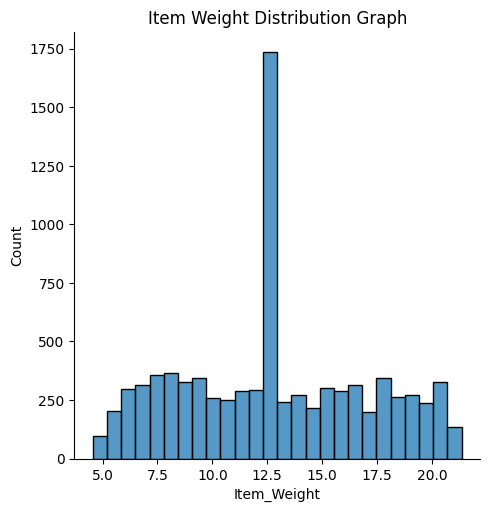

In [78]:
# Plotting the distribution of Item_Weight column

# Set figure size
plt.figure(figsize=(6,6))

# Create distribution plot
# This shows how Item_Weight values are spread in the dataset
sns.displot(dataset['Item_Weight'])

# Add title to the graph
plt.title("Item Weight Distribution Graph")

# Display the graph
plt.show()

<Figure size 600x600 with 0 Axes>

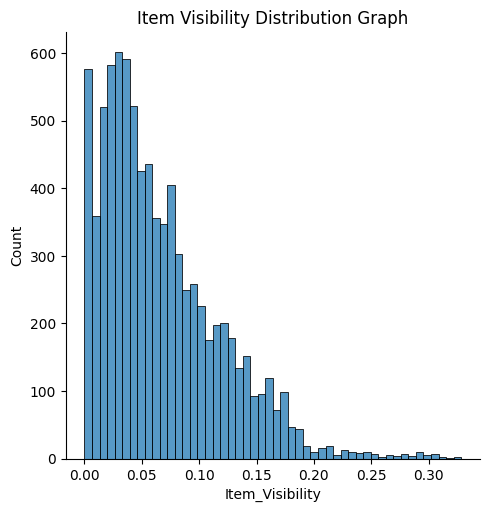

In [79]:
# Plotting the distribution of Item_Visibility values

# Set figure size
plt.figure(figsize=(6,6))

# Create distribution plot
# This helps us understand how Item_Visibility values are distributed
sns.displot(dataset['Item_Visibility'])

# Add title to the graph
plt.title("Item Visibility Distribution Graph")

# Display the graph
plt.show()

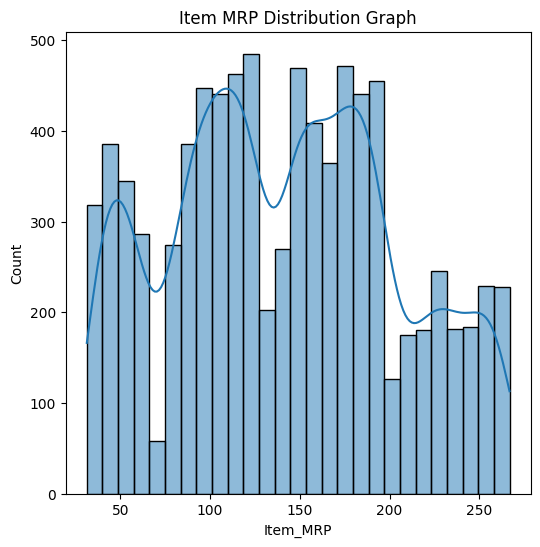

In [80]:
# Histogram for Item_MRP distribution

plt.figure(figsize=(6,6))

# kde=True adds a smooth density curve
sns.histplot(dataset['Item_MRP'], kde=True)

# Graph title
plt.title("Item MRP Distribution Graph")

# Show graph
plt.show()

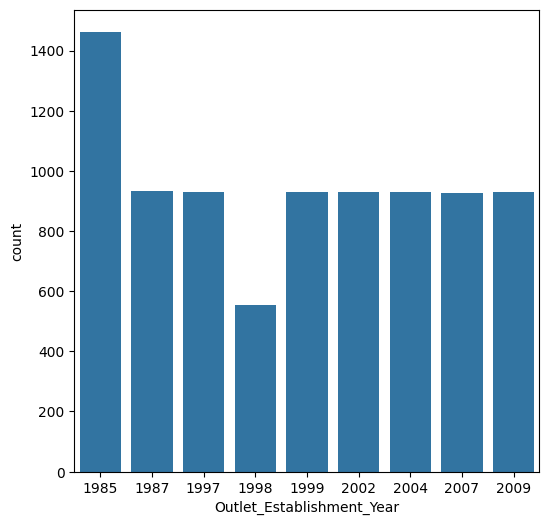

Outlet_Establishment_Year
1985    1463
1987     932
1999     930
1997     930
2004     930
2002     929
2009     928
2007     926
1998     555
Name: count, dtype: int64


In [81]:
# Count plot for Outlet_Establishment_Year

# Set graph size
plt.figure(figsize=(6,6))

# Create count plot
# Shows how many outlets were established in each year
sns.countplot(x='Outlet_Establishment_Year', data=dataset)

# Display graph
plt.show()

# Display count of each establishment year
print(dataset['Outlet_Establishment_Year'].value_counts())

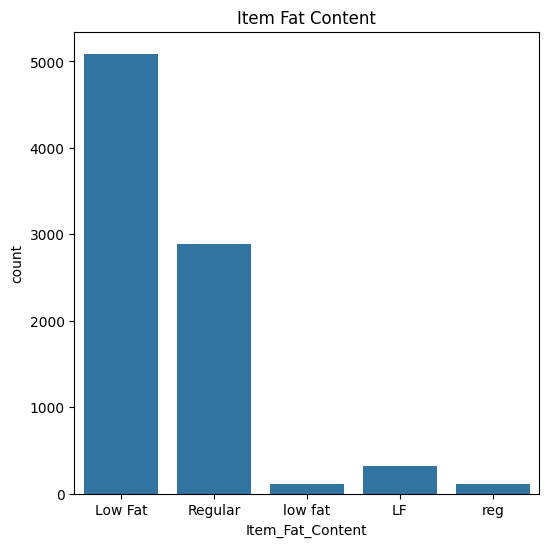

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


In [82]:
# Count plot for Item_Fat_Content

# Set graph size
plt.figure(figsize=(6,6))

# Create count plot
# Shows the number of items in each fat content category
sns.countplot(x='Item_Fat_Content', data=dataset)

# Add title to the graph
plt.title("Item Fat Content")

# Display graph
plt.show()

# Display the count of each Item_Fat_Content category
print(dataset['Item_Fat_Content'].value_counts())

Lf == Low Fat == low fat
reg == Regular

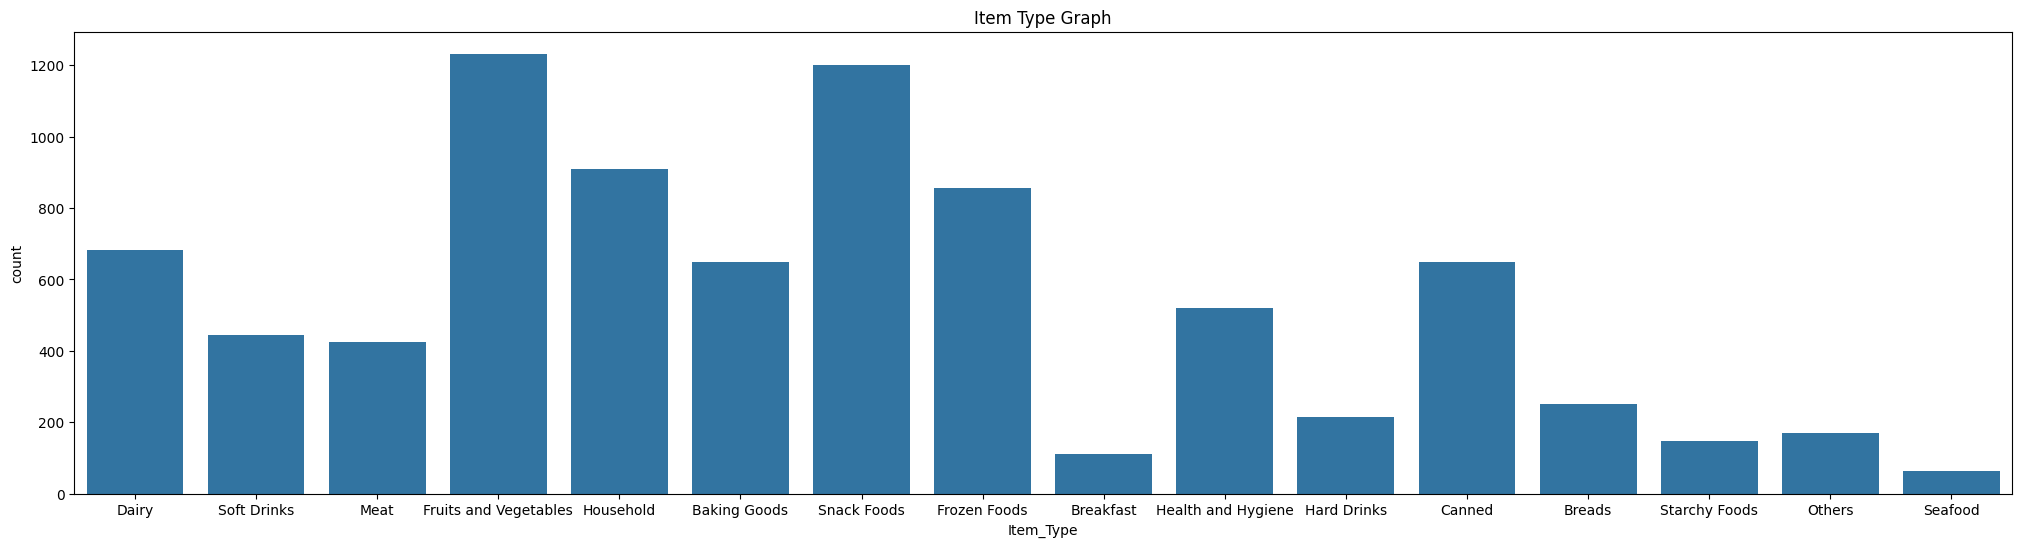

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


In [83]:
# Count plot for Item_Type

# Set graph size
# Large width is used because there are many item categories
plt.figure(figsize=(25,6))

# Create count plot
# Shows the number of items present in each Item_Type category
sns.countplot(x='Item_Type', data=dataset)

# Add title to the graph
plt.title("Item Type Graph")

# Display graph
plt.show()

# Display the count of each Item_Type category
print(dataset['Item_Type'].value_counts())

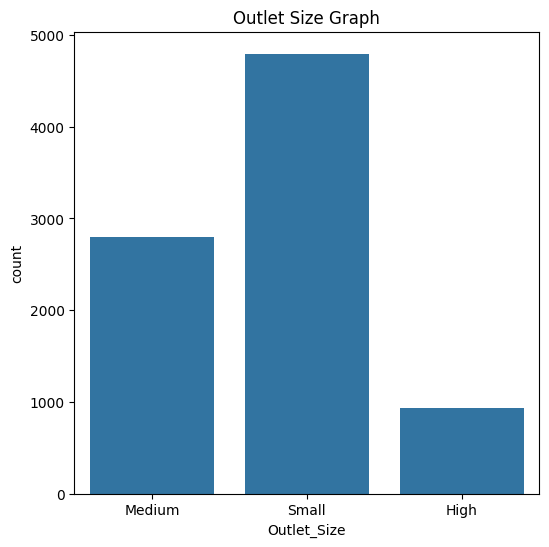

Outlet_Size
Small     4798
Medium    2793
High       932
Name: count, dtype: int64


In [84]:
# Count plot for Outlet_Size

# Set graph size
plt.figure(figsize=(6,6))

# Create count plot
# Shows the number of outlets in each outlet size category
sns.countplot(x='Outlet_Size', data=dataset)

# Add title to the graph
plt.title("Outlet Size Graph")

# Display graph
plt.show()

# Display the count of each Outlet_Size category
print(dataset['Outlet_Size'].value_counts())

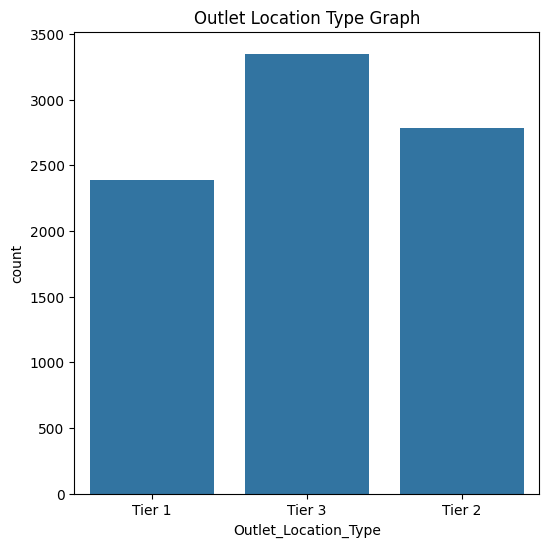

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64


In [85]:
# Count plot for Outlet_Location_Type

# Set graph size
plt.figure(figsize=(6,6))

# Create count plot
# Shows the number of outlets in each location type category
sns.countplot(x='Outlet_Location_Type', data=dataset)

# Add title to the graph
plt.title("Outlet Location Type Graph")

# Display graph
plt.show()

# Display the count of each Outlet_Location_Type category
print(dataset['Outlet_Location_Type'].value_counts())

In [86]:
# Cleaning inconsistent values in the Item_Fat_Content column

# Replace different representations of the same category
# to maintain consistency in the dataset
dataset.replace({
    'Item_Fat_Content': {
        'low fat': 'Low Fat',
        'LF': 'Low Fat',
        'reg': 'Regular'
    }
}, inplace=True)

# Display updated count of each category
print(dataset['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [87]:
# Machine learning models cannot directly understand categorical (text) values
# So we convert categorical data into numerical form using Label Encoding

# Create LabelEncoder object
coder = LabelEncoder()

# Convert Item_Identifier column into numerical values
dataset['Item_Identifier'] = coder.fit_transform(dataset['Item_Identifier'])

# Convert Item_Fat_Content column into numerical values
dataset['Item_Fat_Content'] = coder.fit_transform(dataset['Item_Fat_Content'])

# Convert Item_Type column into numerical values
dataset['Item_Type'] = coder.fit_transform(dataset['Item_Type'])

# Convert Outlet_Identifier column into numerical values
dataset['Outlet_Identifier'] = coder.fit_transform(dataset['Outlet_Identifier'])

# Convert Outlet_Location_Type column into numerical values
dataset['Outlet_Location_Type'] = coder.fit_transform(dataset['Outlet_Location_Type'])

# Convert Outlet_Type column into numerical values
dataset['Outlet_Type'] = coder.fit_transform(dataset['Outlet_Type'])

# Convert Outlet_Size column into numerical values
dataset['Outlet_Size'] = coder.fit_transform(dataset['Outlet_Size'])

In [125]:
# Splitting the dataset into features (X) and target variable (Y)

# X contains all input features used for prediction
# We remove the target column: 'Item_Outlet_Sales'
x = dataset.drop(columns=['Item_Outlet_Sales', 'Item_Identifier', 'Outlet_Identifier'], axis = 1)

# Y contains the target/output variable
# This is the value we want the model to predict
y= dataset['Item_Outlet_Sales']

In [126]:
 regressor = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=2
)
# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=2
)

# Train model
regressor.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [108]:
# Now its time for cleaning the testing data set
testing_dataset.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,1103,20.750000,1,0.007565,13,107.8622,9,1999,1,0,1
1,1067,8.300000,4,0.038428,4,87.3198,2,2007,2,1,1
2,1406,14.600000,1,0.099575,11,241.7538,0,1998,2,2,0
3,809,7.315000,1,0.015388,13,155.0340,2,2007,2,1,1
4,1184,12.695633,2,0.118599,4,234.2300,5,1985,1,2,3


In [109]:
# Check the number of missing (null) values
# present in each column of the testing dataset

testing_dataset.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

In [110]:
# Fill missing values in the "Item_Weight" column
# using the mean (average) value of the column

testing_dataset['Item_Weight'] = testing_dataset['Item_Weight'].fillna(
    testing_dataset['Item_Weight'].mean()
)

In [111]:
# Check the number of missing (null) values
# present in each column of the testing dataset

testing_dataset.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

In [112]:
# Filling missing values in the "Outlet_Size" column
# by finding the most common Outlet_Size for each Outlet_Type

# Create a pivot table:
# - values='Outlet_Size' -> column whose mode we want
# - columns=['Outlet_Type'] -> groups data based on Outlet_Type
# - aggfunc -> finds the most frequent Outlet_Size in each group
mode_of_outlet_size = testing_dataset.pivot_table(
    values='Outlet_Size',
    columns=['Outlet_Type'],
    aggfunc=(lambda x: x.mode()[0])
)

# Display the mode values for each Outlet_Type
print(mode_of_outlet_size)

# Find rows where Outlet_Size has missing values
outlet_size_missing_values = testing_dataset['Outlet_Size'].isnull()

# Replace missing Outlet_Size values
# based on the corresponding Outlet_Type
testing_dataset.loc[outlet_size_missing_values, 'Outlet_Size'] = (
    testing_dataset.loc[outlet_size_missing_values, 'Outlet_Type']
    .apply(lambda x: mode_of_outlet_size[x])
)

Outlet_Type  0  1  2  3
Outlet_Size  2  2  1  1


In [113]:
# Check the number of missing (null) values
# present in each column of the testing dataset

testing_dataset.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

In [114]:
# Machine learning models cannot directly understand categorical values
# So we convert categorical data into numerical values using Label Encoding

# Create LabelEncoder object
coder = LabelEncoder()

# Convert Item_Identifier column into numerical values
testing_dataset['Item_Identifier'] = coder.fit_transform(
    testing_dataset['Item_Identifier']
)

# Convert Item_Fat_Content column into numerical values
testing_dataset['Item_Fat_Content'] = coder.fit_transform(
    testing_dataset['Item_Fat_Content']
)

# Convert Item_Type column into numerical values
testing_dataset['Item_Type'] = coder.fit_transform(
    testing_dataset['Item_Type']
)

# Convert Outlet_Identifier column into numerical values
testing_dataset['Outlet_Identifier'] = coder.fit_transform(
    testing_dataset['Outlet_Identifier']
)

# Convert Outlet_Location_Type column into numerical values
testing_dataset['Outlet_Location_Type'] = coder.fit_transform(
    testing_dataset['Outlet_Location_Type']
)

# Convert Outlet_Type column into numerical values
testing_dataset['Outlet_Type'] = coder.fit_transform(
    testing_dataset['Outlet_Type']
)

# Convert Outlet_Size column into numerical values
testing_dataset['Outlet_Size'] = coder.fit_transform(
    testing_dataset['Outlet_Size']
)

In [115]:
testing_dataset.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,1103,20.750000,1,0.007565,13,107.8622,9,1999,1,0,1
1,1067,8.300000,4,0.038428,4,87.3198,2,2007,2,1,1
2,1406,14.600000,1,0.099575,11,241.7538,0,1998,2,2,0
3,809,7.315000,1,0.015388,13,155.0340,2,2007,2,1,1
4,1184,12.695633,2,0.118599,4,234.2300,5,1985,1,2,3


In [116]:
testing_prediction = pd.DataFrame(regressor.predict(testing_dataset))
testing_prediction.head()


,0
0,1550.991577
1,1234.640991
2,378.441162
3,2229.985352
4,5793.088867


In [127]:
# Predict on test data
test_prediction = regressor.predict(x_test)

# Calculate R² score
score = metrics.r2_score(y_test, test_prediction)

print("R² Score:", score)

R² Score: 0.5794173837114439
